In [ ]:
# Importación de librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

In [ ]:
import pandas as pd

# Carga del dataset
df= "/content/streaming_users_clean.csv"
df_eda= pd.read_csv(df)
df_eda.head()

,user_id,age,subscription_plan,monthly_watch_time_mins,country,favorite_genre,last_login_date,customer_support_tickets,age_falta,watch_falta,genre_falta
0,10000,39,Estándar,805.8,Brasil,Crimen,2025-03-04,4,0,0,0
1,10001,37,Estándar,1173.4,Colombia,Crimen,2019-04-02,2,0,0,0
2,10002,28,Básico,401.0,Colombia,Crimen,2018-04-13,0,0,0,0
3,10003,43,Básico,62.4,Uruguay,Thriller,2021-01-31,0,0,0,0
4,10004,51,Básico,477.8,Perú,Thriller,2020-09-30,1,0,0,0


# Análisis univariado

Gráfico 1: Distribución demográfica - Edad de los Usuarios activos

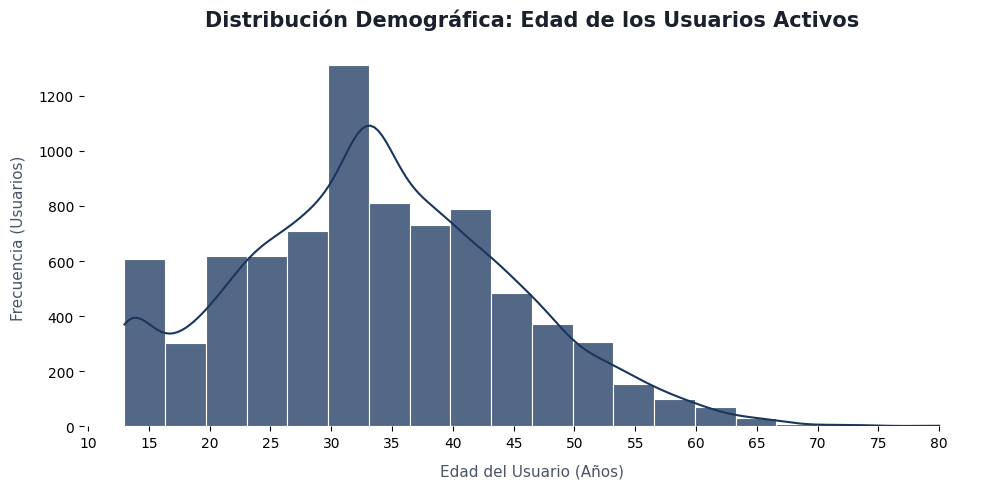

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(10, 5))

# Histograma de Edad estilizado con color corporativo profundo
sns.histplot(
    data=df_eda,
    x='age',
    kde=True,
    color='#1A365D',  # Azul institucional profundo
    alpha=0.75,
    bins=20,           # Cantidad de barras balanceada para rangos de edad
    edgecolor='white',
    linewidth=0.8,
    ax=ax
)

# Títulos y etiquetas profesionales
ax.set_title('Distribución Demográfica: Edad de los Usuarios Activos', fontsize=15, fontweight='bold', pad=15, color='#1A202C')
ax.set_xlabel('Edad del Usuario (Años)', fontsize=11, labelpad=10, color='#4A5568')
ax.set_ylabel('Frecuencia (Usuarios)', fontsize=11, labelpad=10, color='#4A5568')

# Forzamos a que el eje X muestre números enteros claros cada 5 o 10 años, evitando decimales
import matplotlib.ticker as ticker
ax.xaxis.set_major_locator(ticker.MultipleLocator(5))

# Limpieza visual moderna (Despine)
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

La distribución de los usuarios activos se concentra principalmente en un rango de edad madura, desde los 18 años hasta los 65 años, con una clara asimetría hacia la derecha que muestra cómo disminuye la cantidad de usuarios a medida que avanza la edad. El rasgo más notorio del gráfico es la acumulación atípica de frecuencias en el intervalo de 30-35 años, donde los valores faltantes originales fueron reemplazados utilizando las medianas acumuladas según el perfil de consumo (género favorito y plan). Si bien la imputación altera la dustribución de la variable, preserva la coherencia demográfica del negocio, localizando a los usuarios imputados en el núcleo principal de clientes de la plataforma (30-45 años):

Gráfico 2: Volumen de clientes activos por nivel de subscripción

/tmp/ipykernel_1419/1455291068.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


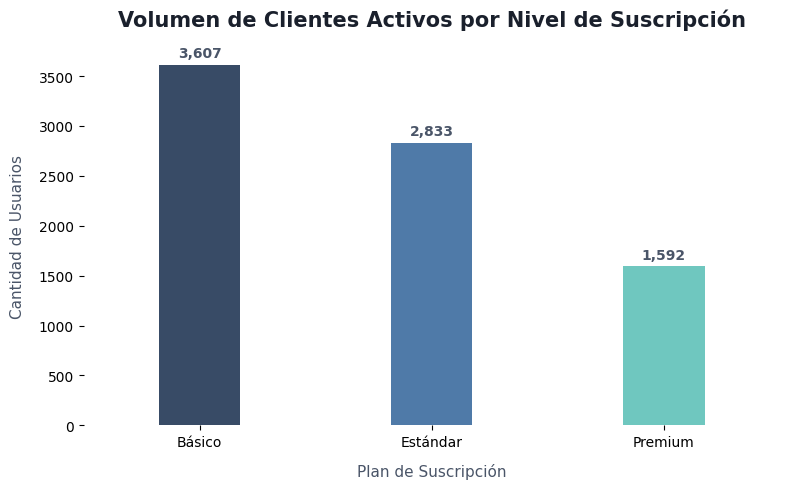

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))

# Definimos el orden descendente
order_plans = df_eda['subscription_plan'].value_counts().index

# Ajustamos width=0.35 para hacer las barras notablemente más finas y estilizadas
sns.countplot(
    data=df_eda,
    x='subscription_plan',
    order=order_plans,
    palette=["#1A365D", "#2B6CB0", "#4FD1C5"],
    alpha=0.9,
    width=0.35,
    ax=ax
)

# Agregar etiquetas de conteo exacto arriba de cada barra
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width() / 2., p.get_height() + 50),
                ha='center', va='center', fontsize=10, fontweight='bold', color='#4A5568', xytext=(0, 5), textcoords='offset points')

# Títulos y etiquetas profesionales
ax.set_title('Volumen de Clientes Activos por Nivel de Suscripción', fontsize=15, fontweight='bold', pad=15, color='#1A202C')
ax.set_xlabel('Plan de Suscripción', fontsize=11, labelpad=10, color='#4A5568')
ax.set_ylabel('Cantidad de Usuarios', fontsize=11, labelpad=10, color='#4A5568')

# Limpieza de bordes
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

El volumen de la base de usuarios presenta una distribución escalonada inversamente proporcional al costo del servicio. El plan básico lidera ampliamente la plataforma con 3.607 usuarios, seguido por el Plan Estándar con 2.833 usuarios, mientras el plan premium concentra el segmento más exclusivo con 1.592 usuarios.

# Análisis bivariado

Gráfico 1: Consumo mensual por segmento de plan

/tmp/ipykernel_1419/3635828191.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


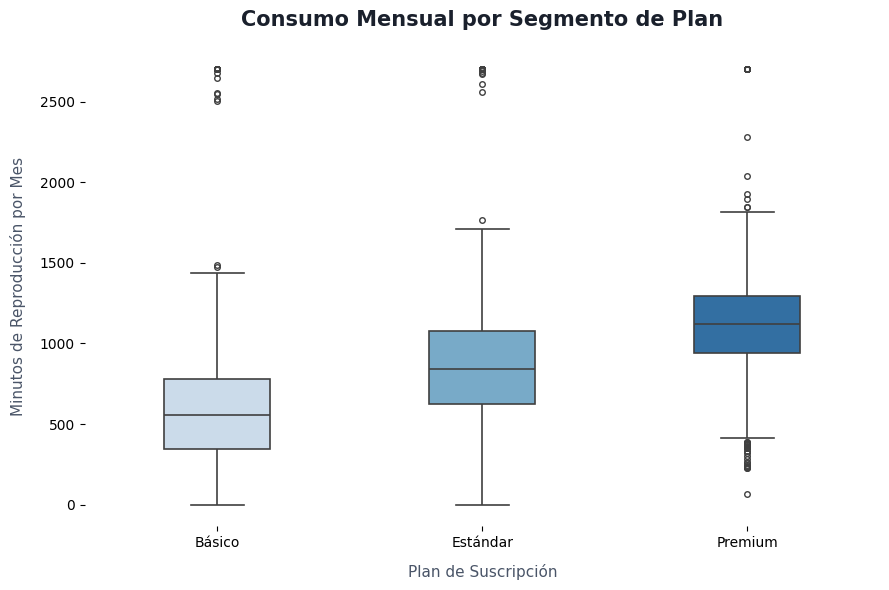

In [ ]:
fig, ax = plt.subplots(figsize=(9, 6))

# Definimos un orden lógico para el negocio (de menor a mayor valor de plan)
orden_planes = ['Básico', 'Estándar', 'Premium']

# Boxplot estilizado y elegante con la paleta Blues
sns.boxplot(
    data=df_eda,
    x='subscription_plan',
    y='monthly_watch_time_mins',
    order=[p for p in orden_planes if p in df_eda['subscription_plan'].unique()], # Validación por si varían los nombres
    palette="Blues",
    width=0.4,        # Barras más finas y estilizadas
    linewidth=1.2,
    fliersize=4,      # Control de tamaño para los outliers (efecto de la winsorización)
    ax=ax
)

# Títulos y etiquetas profesionales en sintonía con tu gráfico de regiones
ax.set_title('Consumo Mensual por Segmento de Plan', fontsize=15, fontweight='bold', pad=15, color='#1A202C')
ax.set_xlabel('Plan de Suscripción', fontsize=11, labelpad=10, color='#4A5568')
ax.set_ylabel('Minutos de Reproducción por Mes', fontsize=11, labelpad=10, color='#4A5568')

# Limpieza visual moderna de bordes (Despine)
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()

El boxplot es un diagrama de caja y bigotes que permite analizar de forma simultánea la tendencia central, la dispersión y la presencia de anomalías de consumo en cada plan. Hay una relación directa entre el nivel del plan de subscripción y el tiempo de permanencia en la plataforma: a medida que se escala en la jerarquía comercial del plan, aumentan los minutos de reproducción por mes. El plan básico presenta un consumo centralizado en torno a los 600 minutos mensuales; el plan estándar en torno a los 950 minutos y el plan premium por encima de 12000 minutos. El tamaño de las cajas se mantiene relativamente homogeneo en los grupos, lo que demuestra que la variabilidad del comportamiento de los usuarios es estable dentro de cada categoría, confirmando que el tipo de plan es un fuerte predictor del volumen de reproducción. Por último, los puntos aislados representan outliers, es decir, usuarios con consumo elevado en planes económicos. Su identificación es muy importante, para la actualización de los planes.

Gráfico 2: Análisis de Preferencia de Contenido por Región Geográfica

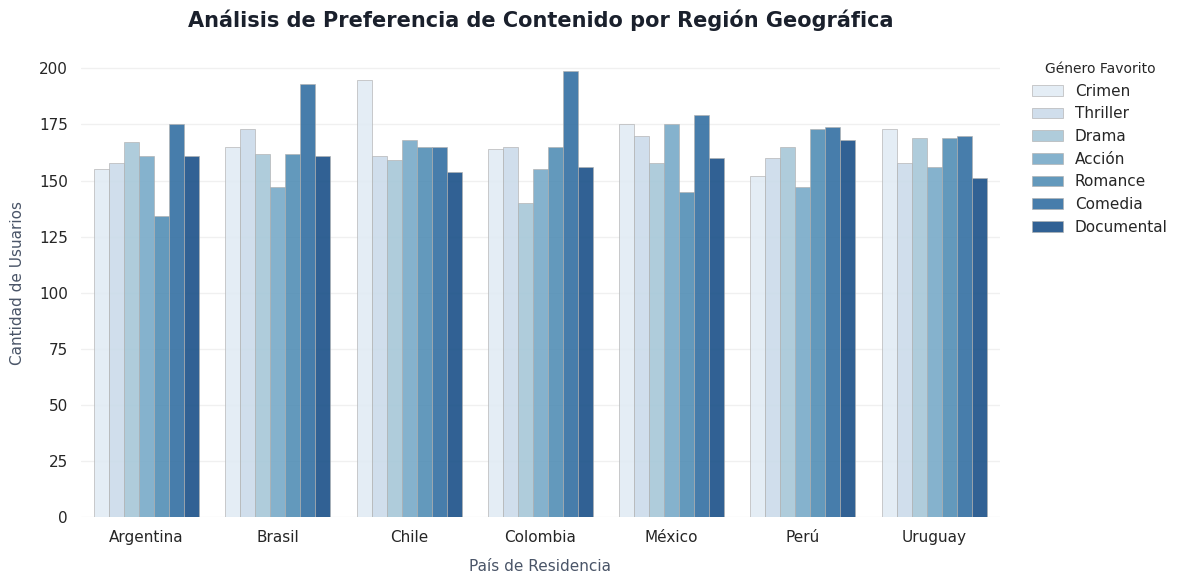

In [ ]:
# --- Configuración Estética Base ---
sns.set_theme(style="whitegrid", rc={
    "font.family": "sans-serif",
    "grid.color": "#f0f0f0",
    "axes.edgecolor": "#d0d0d0"
})

# --- Gráfico Bivariado: Género por Región con Paleta 'Blues' ---
fig, ax = plt.subplots(figsize=(12, 6))

# Agrupado por país, usando la paleta secuencial 'Blues'
# Se ordenan los países alfabéticamente para mayor claridad visual
sns.countplot(
    data=df_eda,
    x='country',
    hue='favorite_genre',
    palette="Blues",  # Aplicamos la paleta Blues solicitada
    alpha=0.9,
    order=sorted(df_eda['country'].unique()),
    edgecolor='#b0b0b0', # Un borde sutil para definir mejor las barras claras
    linewidth=0.5,
    ax=ax
)

# Títulos y etiquetas profesionales alineados con el resto del reporte
ax.set_title('Análisis de Preferencia de Contenido por Región Geográfica', fontsize=15, fontweight='bold', pad=15, color='#1A202C')
ax.set_xlabel('País de Residencia', fontsize=11, labelpad=10, color='#4A5568')
ax.set_ylabel('Cantidad de Usuarios', fontsize=11, labelpad=10, color='#4A5568')

# Leyenda corporativa flotante a la derecha, para no pisar las barras
ax.legend(
    title='Género Favorito',
    title_fontsize='10',
    loc='upper left',
    bbox_to_anchor=(1.02, 1),
    frameon=False
)

# Limpieza visual moderna de bordes (Despine)
sns.despine(left=True, bottom=True)

# Ajuste automático del layout para que no se corte la leyenda
plt.tight_layout()
plt.show()

Este gráfico cruza dos variables categóricas: país de residencia y la distribución de frecuencias de los géneros favoritos de conteniod. El aspecto más relevante para el análsis es la notable homogeneidad en el volumen total de usuarios por país, ya que ninguna región geográfica domina sobre las demás, mostrando un mercado estable en los diferentes países. Lo mismo sucede con los géneros, aunque se pueden identificar microtendencias de preferencia en categorías específicas dentro de mercados claves como Brasil, Chile y Colombia, donde géneros como el crimen (Chile) o la comedia (Brasil y Colombia) sobresalen por encima dekl promedio. Esto permite aplicar unas estrategias de marketing y no otras.

# Análisis multivariado

Gráfico: Relación de edad y consumo por plan de subscripción

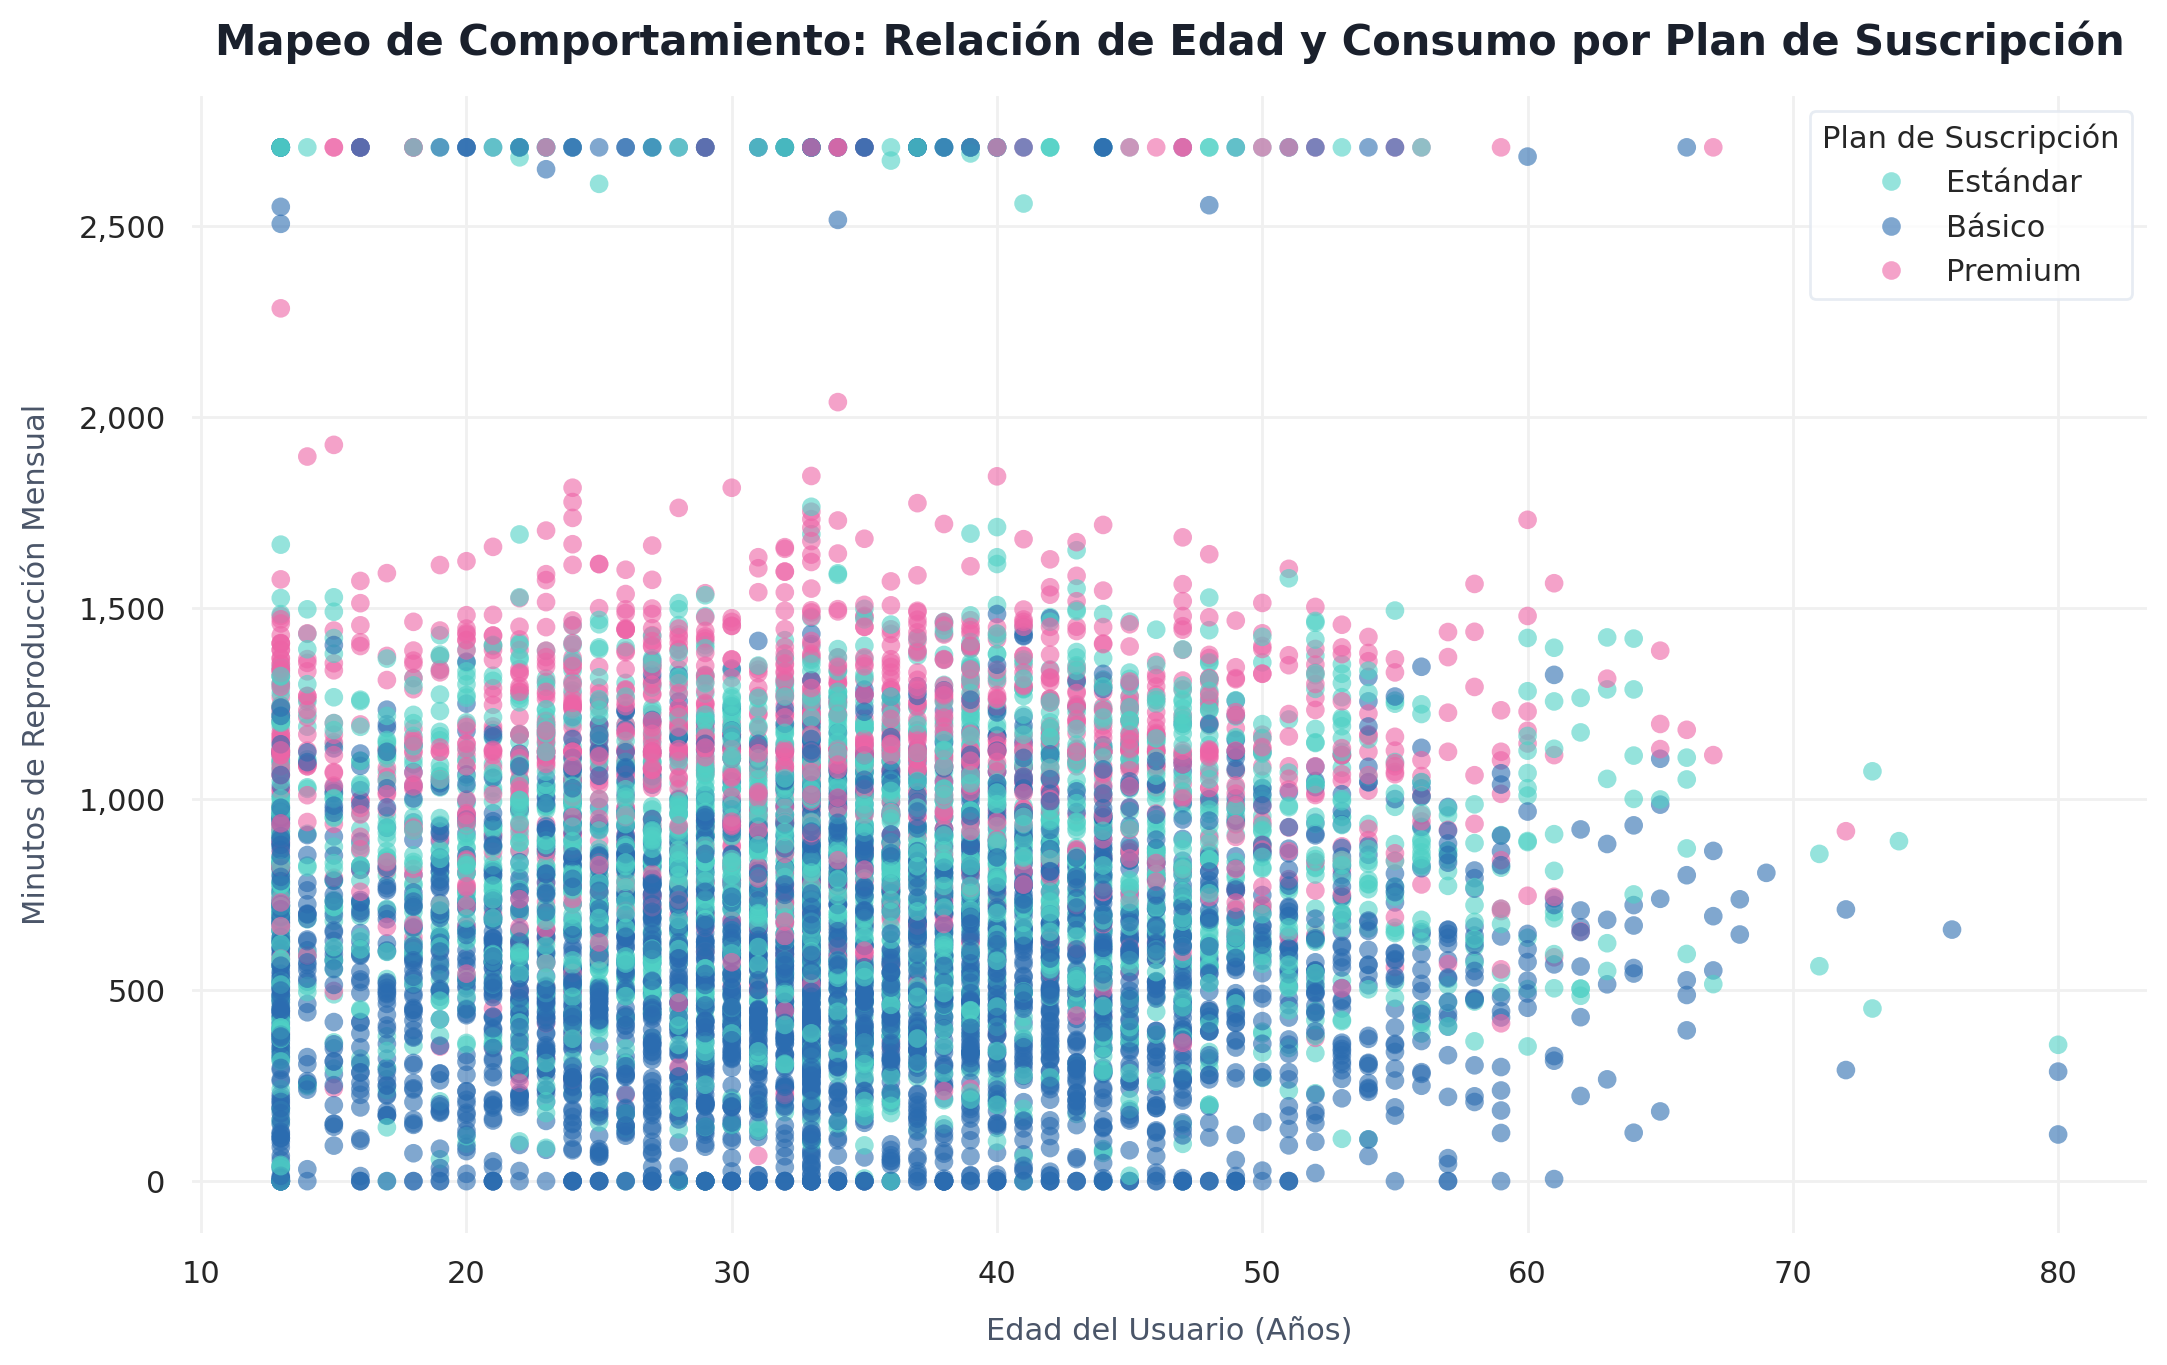

In [ ]:
# 1. Configuración de estilo
%config InlineBackend.figure_format = 'retina'
sns.set_theme(style="whitegrid", rc={
    "axes.facecolor": "#FFFFFF",
    "grid.color": "#f0f0f0",
    "font.family": "sans-serif"
})

# 2. Paleta de colores multivariado profesional
PLATFORM_PALETTE = {
    "Básico": "#2B6CB0",     # Azul intermedio
    "Estándar": "#4FD1C5",   # Turquesa
    "Premium": "#ED64A6"     # Rosa/Magenta corporativo
}

fig, ax = plt.subplots(figsize=(11, 7))

# 3. Gráfico multivariado: Scatter plot con transparencia para evitar el overplotting
sns.scatterplot(
    data=df_eda,
    x='age',
    y='monthly_watch_time_mins',
    hue='subscription_plan',
    palette=PLATFORM_PALETTE,
    alpha=0.6,
    s=45,
    edgecolor='none',
    ax=ax
)

# 4. Títulos y etiquetas profesionales (Jerarquizados)
ax.set_title('Mapeo de Comportamiento: Relación de Edad y Consumo por Plan de Suscripción', fontsize=15, fontweight='bold', pad=15, color='#1A202C')
ax.set_xlabel('Edad del Usuario (Años)', fontsize=11, labelpad=10, color='#4A5568')
ax.set_ylabel('Minutos de Reproducción Mensual', fontsize=11, labelpad=10, color='#4A5568')

# 5. Formateo y limpieza de los ejes (Evita decimales y amontona números)
ax.xaxis.set_major_locator(ticker.MultipleLocator(10)) # Muestra marcas cada 10 años
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ','))) # Formato entero con miles

# 6. Ajuste estético de la leyenda institucional
ax.legend(
    title='Plan de Suscripción',
    title_fontsize='11',
    loc='upper right',
    frameon=True,
    facecolor='white',
    edgecolor='#e2e8f0'
)

# 7. Remoción moderna de bordes exteriores
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()

Este Scatter Plot integra de forma simultánea tres dimensiones clave: Edad, minutos de reproducción mensual y plan de subscripción y revela patrones de comportamiento muy claros: el engagement de la plataforma no depende únicamente de la edad del usuario, sino que está fuertemente correlacionada con el nivel de susbscripción que adquieren. El segmento premium no solo paga más, sino que efcetivamente valida su pago consumiendo un volumen de contenido significativamente mayor.